# Loan Approval Prediction using Explainable AI (SHAP & LIME)

## 1. Introduction & Problem Statement

The rapid growth of financial services has increased the need for efficient and reliable loan approval systems. Traditional decision-making processes are often time-consuming and may lack consistency, leading to potential biases and inefficiencies. Machine learning models offer a scalable solution by automating the prediction of loan approval based on applicant features such as income, credit score, and financial history.

However, a major challenge in deploying such models is the lack of interpretability. Many machine learning models, especially ensemble methods, behave as black boxes, making it difficult to understand the reasoning behind their predictions. This lack of transparency is a critical concern in financial domains, where decisions must be explainable and trustworthy.

In addition, real-world datasets often suffer from class imbalance, where one class (e.g., approved loans) significantly outnumbers the other. This imbalance can lead to biased models that perform poorly in identifying minority cases, which are often more important from a risk perspective.

This project aims to address these challenges by developing a loan approval prediction model using machine learning techniques, while incorporating Explainable AI (XAI) methods such as SHAP and LIME to enhance interpretability. Furthermore, techniques like SMOTE are applied to handle class imbalance and improve model performance on minority classes.

The objective is to build a predictive system that is not only accurate but also transparent, interpretable, and reliable for real-world financial decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("loan_prediction_dataset.csv")
df.head()

,age,income,credit_score,dependents,home_owner,loan_approved
0,54,100000.00,334,0,1,1
1,67,85233.42,593,2,1,1
2,29,16737.15,502,0,0,1
3,42,69332.50,367,3,0,0
4,58,28211.14,430,0,1,1


## 2. Dataset and Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1000 non-null   int64  
 1   income         1000 non-null   float64
 2   credit_score   1000 non-null   int64  
 3   dependents     1000 non-null   int64  
 4   home_owner     1000 non-null   int64  
 5   loan_approved  1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


In [4]:
df.describe()

,age,income,credit_score,dependents,home_owner,loan_approved
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,44.54400,31943.240590,573.644000,2.027000,0.494000,0.782000
std,13.95345,28058.315386,163.781078,1.422074,0.500214,0.413094
min,20.00000,4000.000000,300.000000,0.000000,0.000000,0.000000
25%,33.00000,11057.325000,423.500000,1.000000,0.000000,1.000000
50%,44.00000,21712.035000,572.000000,2.000000,0.000000,1.000000
75%,57.00000,42369.575000,720.000000,3.000000,1.000000,1.000000
max,69.00000,100000.000000,849.000000,4.000000,1.000000,1.000000


In [5]:
df.shape

(1000, 6)

In [6]:
df.isna().sum()

age              0
income           0
credit_score     0
dependents       0
home_owner       0
loan_approved    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['loan_approved'] = df['loan_approved'].astype(int)

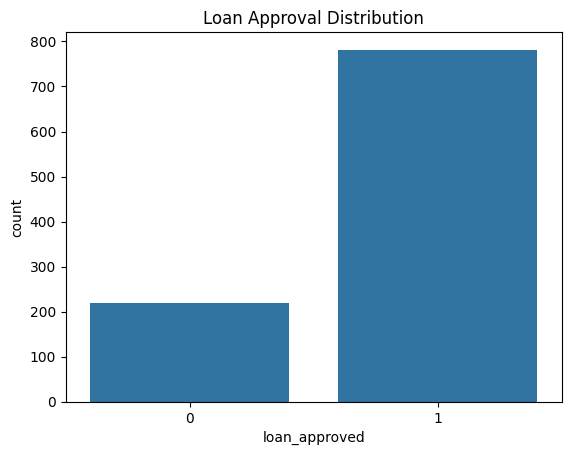

In [9]:
sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.show()

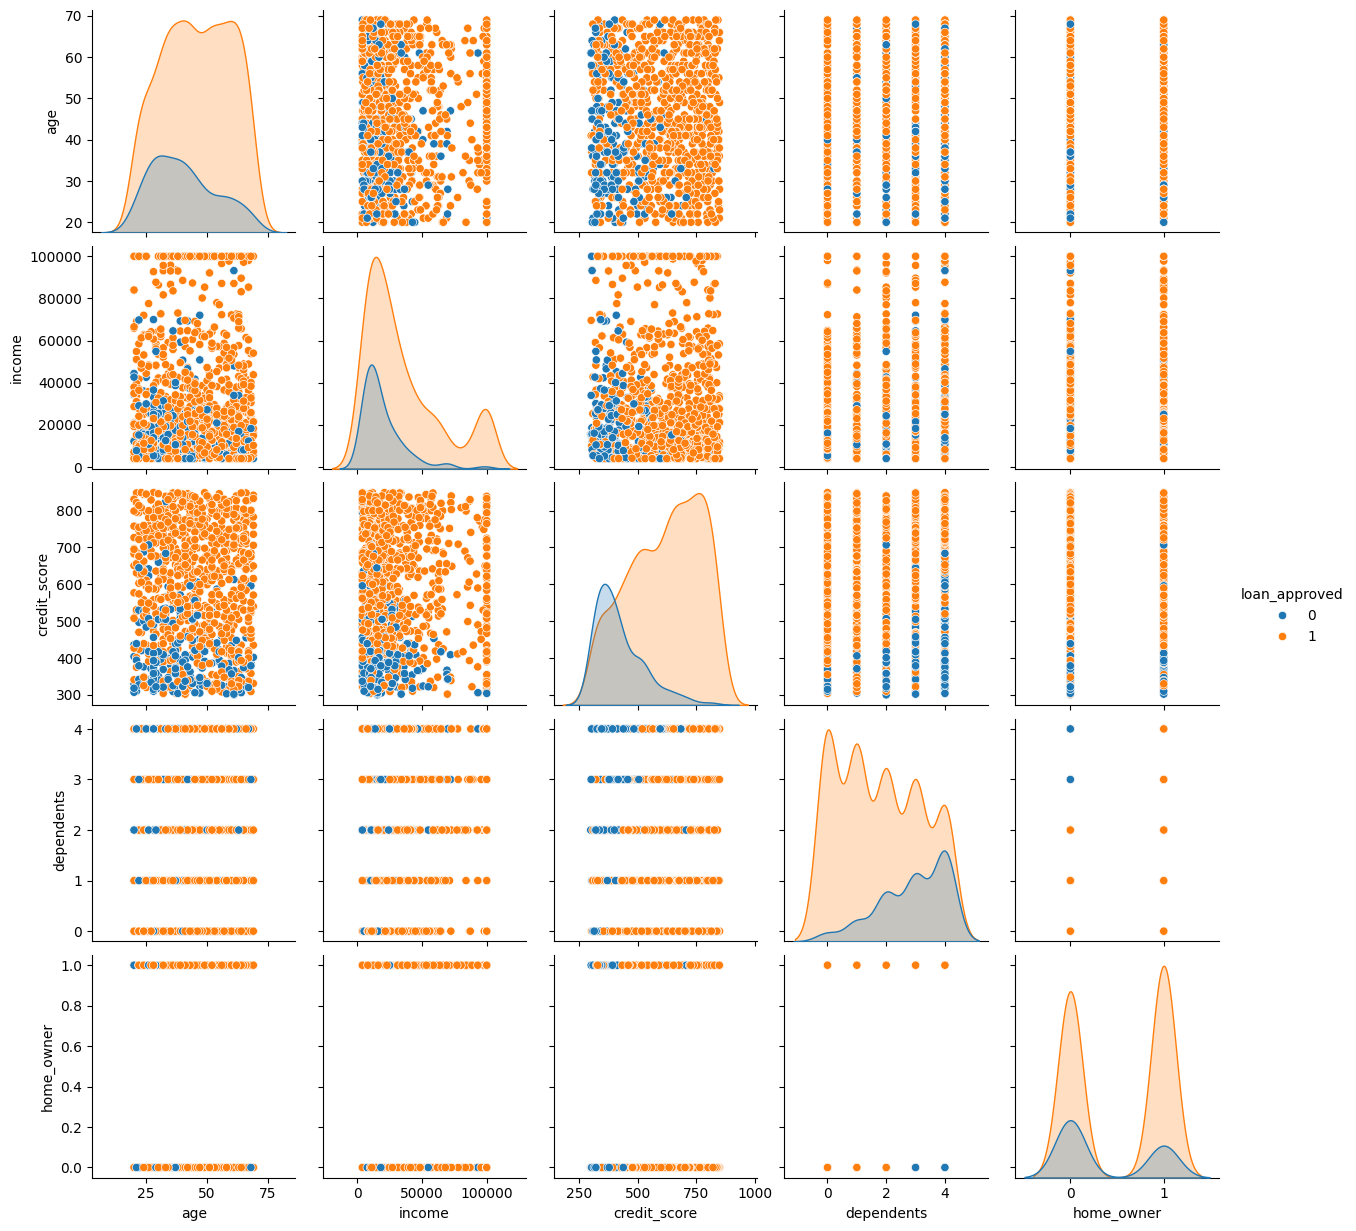

In [10]:
sns.pairplot(df, hue='loan_approved')
plt.show()

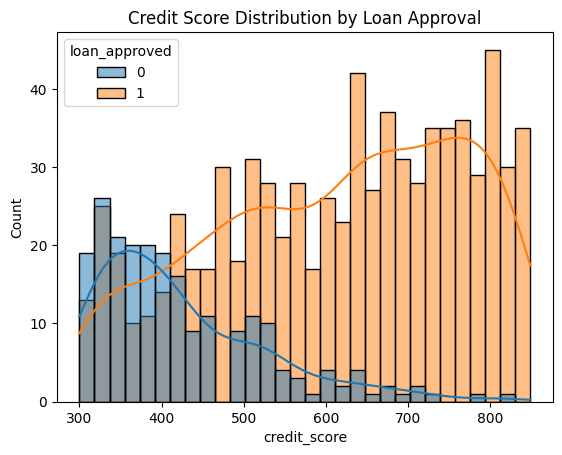

In [11]:
sns.histplot(data=df, x='credit_score', hue='loan_approved', bins=30, kde=True)
plt.title("Credit Score Distribution by Loan Approval")
plt.show()

## 3. Data Preprocessing and Handling Imbalance (SMOTE)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape

(800, 5)

In [16]:
X_test.shape

(200, 5)

In [17]:
from imblearn.over_sampling import SMOTE 

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X, y)

## 4. Model Training and Evaluation

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [19]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print("Logistic Regression (Original)")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

Logistic Regression (Original)
Accuracy: 0.905
              precision    recall  f1-score   support

           0       0.84      0.66      0.74        41
           1       0.92      0.97      0.94       159

    accuracy                           0.91       200
   macro avg       0.88      0.81      0.84       200
weighted avg       0.90      0.91      0.90       200



In [20]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("Random Forest (Original)")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest (Original)
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.74      0.63      0.68        41
           1       0.91      0.94      0.93       159

    accuracy                           0.88       200
   macro avg       0.83      0.79      0.81       200
weighted avg       0.88      0.88      0.88       200



In [21]:
# Logistic Regression (SMOTE)
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_res, y_train_res)

lr_smote_preds = lr_smote.predict(X_test)

print("Logistic Regression (SMOTE)")
print("Accuracy:", accuracy_score(y_test, lr_smote_preds))
print(classification_report(y_test, lr_smote_preds))

Logistic Regression (SMOTE)
Accuracy: 0.915
              precision    recall  f1-score   support

           0       0.73      0.93      0.82        41
           1       0.98      0.91      0.94       159

    accuracy                           0.92       200
   macro avg       0.86      0.92      0.88       200
weighted avg       0.93      0.92      0.92       200



In [22]:
# Random Forest (SMOTE)
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_smote.fit(X_train_res, y_train_res)

rf_smote_preds = rf_smote.predict(X_test)

print("Random Forest (SMOTE)")
print("Accuracy:", accuracy_score(y_test, rf_smote_preds))
print(classification_report(y_test, rf_smote_preds))

Random Forest (SMOTE)
Accuracy: 0.93
              precision    recall  f1-score   support

           0       0.76      0.95      0.85        41
           1       0.99      0.92      0.95       159

    accuracy                           0.93       200
   macro avg       0.88      0.94      0.90       200
weighted avg       0.94      0.93      0.93       200



| Model                 | Data Type | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) |
| --------------------- | --------- | -------- | ------------------- | ---------------- | ------------------ |
| Logistic Regression   | Original  | 0.905    | 0.84                | 0.66             | 0.74               |
| Random Forest         | Original  | 0.88     | 0.74                | 0.63             | 0.68               |
| Logistic Regression   | SMOTE     | 0.915    | 0.73                | 0.93             | 0.82               |
| Random Forest (Tuned) | SMOTE     | **0.93** | 0.76                | **0.95**         | **0.85**           |


The results show that class imbalance negatively affects model performance, particularly for the minority class. Applying SMOTE significantly improved recall, especially for Random Forest, which achieved the best overall balance with 93% accuracy and 0.95 recall for the minority class. This demonstrates that handling imbalance is crucial for building reliable and fair predictive models.

## 5. Explainable AI (SHAP & LIME)

In [23]:
import shap

explainer = shap.TreeExplainer(rf_smote)

shap_values = explainer(X_test)

# Select ONLY class 1 (approved class)
shap_values_class1 = shap_values[:, :, 1]

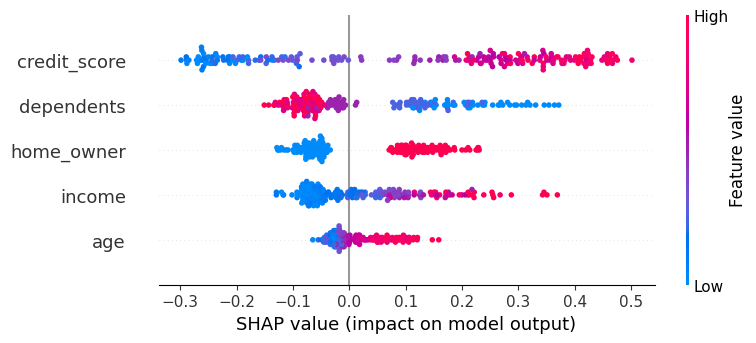

In [32]:
shap.plots.beeswarm(shap_values_class1, show=False)

plt.gcf().savefig("beeswarm_plot.png", bbox_inches='tight')
plt.show()

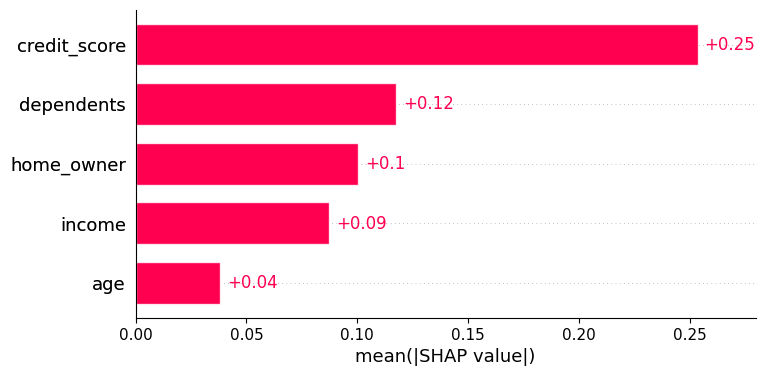

In [25]:
shap.plots.bar(shap_values_class1)

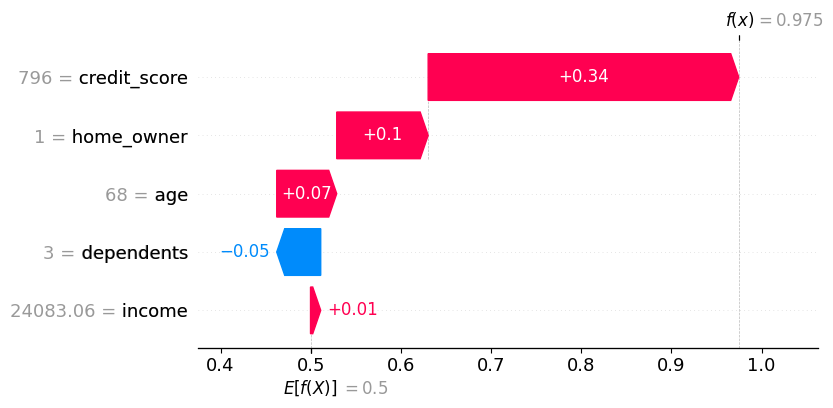

In [26]:
shap.plots.waterfall(shap_values_class1[0], show=False)
plt.savefig("waterfall_plot.png", bbox_inches='tight')
plt.show()

## Explainable AI (SHAP Analysis)

To enhance model interpretability, SHAP (SHapley Additive exPlanations) was applied to the Random Forest model trained on SMOTE-balanced data.

The SHAP summary plot indicates that **credit score** is the most influential feature, followed by **dependents**, **home ownership**, **income**, and **age**. Higher credit scores strongly increase the likelihood of loan approval, while a greater number of dependents negatively impacts the decision.

Home ownership positively contributes to approval, reflecting financial stability, whereas income has a moderate influence. Age shows minimal impact on the model's predictions.

The results from SHAP are consistent with the exploratory data analysis, reinforcing the reliability of the model’s decision-making process. Additionally, local explanations using SHAP confirm that individual predictions are primarily driven by credit score and key financial indicators.

In [27]:
from lime.lime_tabular import LimeTabularExplainer

In [28]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    mode="classification"
)

In [29]:
exp = explainer_lime.explain_instance(
    X_test.iloc[0].values,
    rf_smote.predict_proba
)

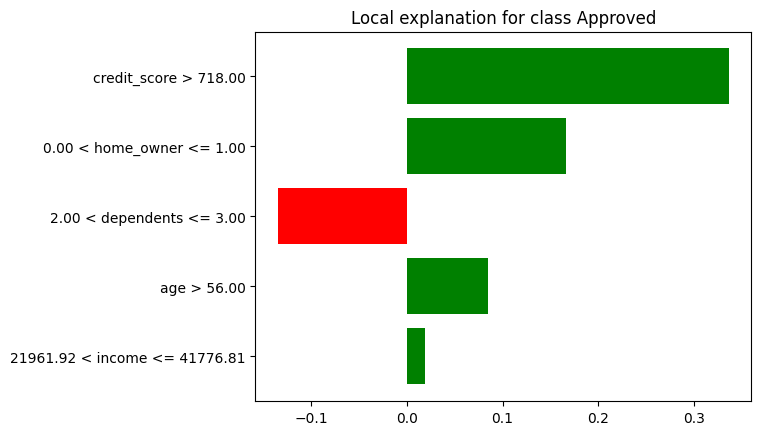

In [30]:
fig = exp.as_pyplot_figure()

fig.savefig("lime_plot.png", bbox_inches='tight')
plt.show()

## Explainable AI (LIME Analysis)

To complement SHAP-based global interpretability, LIME was used to generate local explanations for individual predictions.

The LIME results indicate that features such as credit score, home ownership, and income positively influence loan approval, while a higher number of dependents negatively impacts the prediction.

These local explanations are consistent with SHAP findings, confirming that the model's decisions are driven by meaningful and interpretable feature relationships.

## Conclusion

This study demonstrates that machine learning models can effectively predict loan approval decisions, with Random Forest achieving the best overall performance. Addressing class imbalance using SMOTE significantly improved the model’s ability to detect minority cases, making predictions more reliable and fair.

Furthermore, Explainable AI techniques such as SHAP and LIME provided clear insights into model behavior, highlighting credit score, home ownership, and financial stability as key factors influencing decisions. Overall, the proposed approach combines accuracy with interpretability, making it suitable for real-world financial applications.